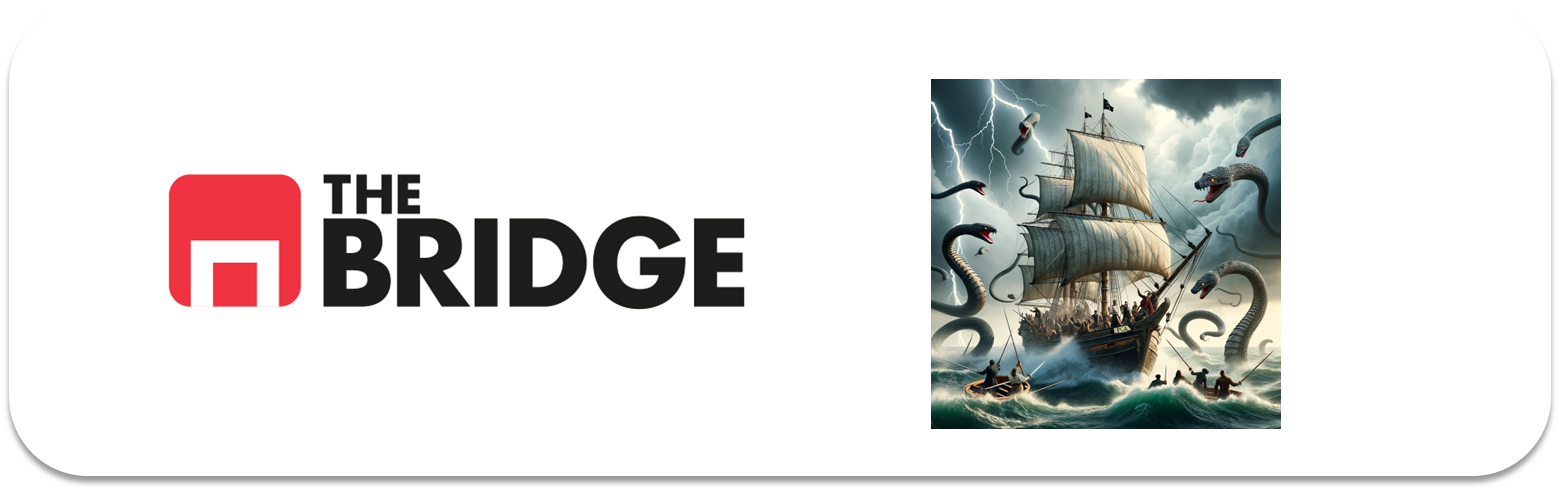

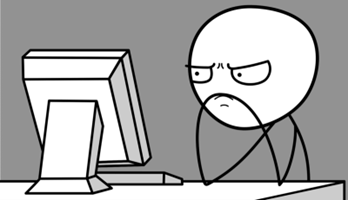

Para ejercitarte y afianzar lo aprendido sobre **PCA**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)

La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

# Principal Components Analysis: Nutrition
En esta colección de ejercicios no vas a montar ningún modelo de Machine Learning supervisado, sino que vas a practicar con PCA: pretratar el dato antes de calcular sus PCs, interpretarlas, pintar y escoger número de componentes según varianza.


### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [7]:
# Tratamiento de datos
# ==============================================================================
import numpy as np
import pandas as pd
import statsmodels.api as sm
import seaborn as sns
# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
import matplotlib.font_manager
from matplotlib import style
style.use('ggplot') or plt.style.use('ggplot')

# Preprocesado y modelado
# ==============================================================================
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import scale

# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

### Ejercicio 1: Importa los datos
1. Importa los datos: *nutrition.csv*
2. Observa las columnas que hay, así como su tipo.

In [6]:
df = pd.read_csv('./data/nutrition.csv')
df.head(10)


,ID,FoodGroup,ShortDescrip,Descrip,CommonName,MfgName,ScientificName,Energy_kcal,Protein_g,Fat_g,...,Folate_USRDA,Niacin_USRDA,Riboflavin_USRDA,Thiamin_USRDA,Calcium_USRDA,Copper_USRDA,Magnesium_USRDA,Phosphorus_USRDA,Selenium_USRDA,Zinc_USRDA
0,1001,Dairy and Egg Products,"BUTTER,WITH SALT","Butter, salted",NaN,NaN,NaN,717.0,0.85,81.11,...,0.0075,0.002625,0.026154,0.004167,0.020000,0.000000,0.004762,0.034286,0.018182,0.008182
1,1002,Dairy and Egg Products,"BUTTER,WHIPPED,WITH SALT","Butter, whipped, with salt",NaN,NaN,NaN,717.0,0.85,81.11,...,0.0075,0.002625,0.026154,0.004167,0.020000,0.000018,0.004762,0.032857,0.018182,0.004545
2,1003,Dairy and Egg Products,"BUTTER OIL,ANHYDROUS","Butter oil, anhydrous",NaN,NaN,NaN,876.0,0.28,99.48,...,0.0000,0.000188,0.003846,0.000833,0.003333,0.000001,0.000000,0.004286,0.000000,0.000909
3,1004,Dairy and Egg Products,"CHEESE,BLUE","Cheese, blue",NaN,NaN,NaN,353.0,21.40,28.74,...,0.0900,0.063500,0.293846,0.024167,0.440000,0.000044,0.054762,0.552857,0.263636,0.241818
4,1005,Dairy and Egg Products,"CHEESE,BRICK","Cheese, brick",NaN,NaN,NaN,371.0,23.24,29.68,...,0.0500,0.007375,0.270000,0.011667,0.561667,0.000027,0.057143,0.644286,0.263636,0.236364
5,1006,Dairy and Egg Products,"CHEESE,BRIE","Cheese, brie",NaN,NaN,NaN,334.0,20.75,27.68,...,0.1625,0.023750,0.400000,0.058333,0.153333,0.000021,0.047619,0.268571,0.263636,0.216364
6,1007,Dairy and Egg Products,"CHEESE,CAMEMBERT","Cheese, camembert",NaN,NaN,NaN,300.0,19.80,24.26,...,0.1550,0.039375,0.375385,0.023333,0.323333,0.000023,0.047619,0.495714,0.263636,0.216364
7,1008,Dairy and Egg Products,"CHEESE,CARAWAY","Cheese, caraway",NaN,NaN,NaN,376.0,25.18,29.20,...,0.0450,0.011250,0.346154,0.025833,0.560833,0.000027,0.052381,0.700000,0.263636,0.267273
8,1009,Dairy and Egg Products,"CHEESE,CHEDDAR","Cheese, cheddar",NaN,NaN,NaN,406.0,24.04,33.82,...,0.0650,0.002437,0.333846,0.022500,0.562500,0.000062,0.064286,0.675714,0.514545,0.311818
9,1010,Dairy and Egg Products,"CHEESE,CHESHIRE","Cheese, cheshire",NaN,NaN,NaN,387.0,23.37,30.60,...,0.0450,0.005000,0.225385,0.038333,0.535833,0.000047,0.050000,0.662857,0.263636,0.253636


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8618 entries, 0 to 8617
Data columns (total 45 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                8618 non-null   int64  
 1   FoodGroup         8618 non-null   object 
 2   ShortDescrip      8618 non-null   object 
 3   Descrip           8618 non-null   object 
 4   CommonName        1063 non-null   object 
 5   MfgName           1560 non-null   object 
 6   ScientificName    732 non-null    object 
 7   Energy_kcal       8618 non-null   float64
 8   Protein_g         8618 non-null   float64
 9   Fat_g             8618 non-null   float64
 10  Carb_g            8618 non-null   float64
 11  Sugar_g           8618 non-null   float64
 12  Fiber_g           8618 non-null   float64
 13  VitA_mcg          8618 non-null   float64
 14  VitB6_mg          8618 non-null   float64
 15  VitB12_mcg        8618 non-null   float64
 16  VitC_mg           8618 non-null   float64


In [4]:
df.describe()

,ID,Energy_kcal,Protein_g,Fat_g,Carb_g,Sugar_g,Fiber_g,VitA_mcg,VitB6_mg,VitB12_mcg,...,Folate_USRDA,Niacin_USRDA,Riboflavin_USRDA,Thiamin_USRDA,Calcium_USRDA,Copper_USRDA,Magnesium_USRDA,Phosphorus_USRDA,Selenium_USRDA,Zinc_USRDA
count,8618.000000,8618.000000,8618.00000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,...,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000
mean,15467.757368,226.438617,11.52391,10.647024,21.819062,6.560253,2.023242,93.968786,0.264369,1.225260,...,0.125765,0.213222,0.182499,0.174881,0.061176,0.000191,0.077965,0.222838,0.229363,0.179111
std,9221.428766,169.388910,10.55059,15.866353,27.239000,13.602098,4.313670,779.362205,0.478614,4.319183,...,0.466402,0.302161,0.346062,0.431974,0.167803,0.000615,0.133496,0.290133,0.514406,0.305292
min,1001.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8695.250000,93.000000,2.47000,0.992500,0.040000,0.000000,0.000000,0.000000,0.034250,0.000000,...,0.000000,0.023875,0.035385,0.025000,0.007500,0.000033,0.023810,0.052857,0.001818,0.020909
50%,14273.000000,191.000000,8.28500,5.235000,8.945000,0.370000,0.300000,1.500000,0.120000,0.080000,...,0.017500,0.131250,0.115385,0.064583,0.015833,0.000088,0.047619,0.190000,0.070909,0.076818
75%,20050.750000,336.000000,19.97750,13.900000,32.900000,5.300000,2.400000,21.000000,0.355000,1.297500,...,0.062500,0.314328,0.200000,0.185833,0.051667,0.000161,0.069048,0.308571,0.387273,0.245455
max,93600.000000,902.000000,88.32000,100.000000,100.000000,99.800000,79.000000,30000.000000,12.000000,98.890000,...,14.702500,7.968750,13.461538,19.479167,6.136667,0.016722,1.859524,14.168571,34.854545,8.268182


### Ejercicio 2


Analiza la correlación entre las variables numéricas. 

Columnas numéricas: ['ID', 'Energy_kcal', 'Protein_g', 'Fat_g', 'Carb_g', 'Sugar_g', 'Fiber_g', 'VitA_mcg', 'VitB6_mg', 'VitB12_mcg', 'VitC_mg', 'VitE_mg', 'Folate_mcg', 'Niacin_mg', 'Riboflavin_mg', 'Thiamin_mg', 'Calcium_mg', 'Copper_mcg', 'Iron_mg', 'Magnesium_mg', 'Manganese_mg', 'Phosphorus_mg', 'Selenium_mcg', 'Zinc_mg', 'VitA_USRDA', 'VitB6_USRDA', 'VitB12_USRDA', 'VitC_USRDA', 'VitE_USRDA', 'Folate_USRDA', 'Niacin_USRDA', 'Riboflavin_USRDA', 'Thiamin_USRDA', 'Calcium_USRDA', 'Copper_USRDA', 'Magnesium_USRDA', 'Phosphorus_USRDA', 'Selenium_USRDA', 'Zinc_USRDA']


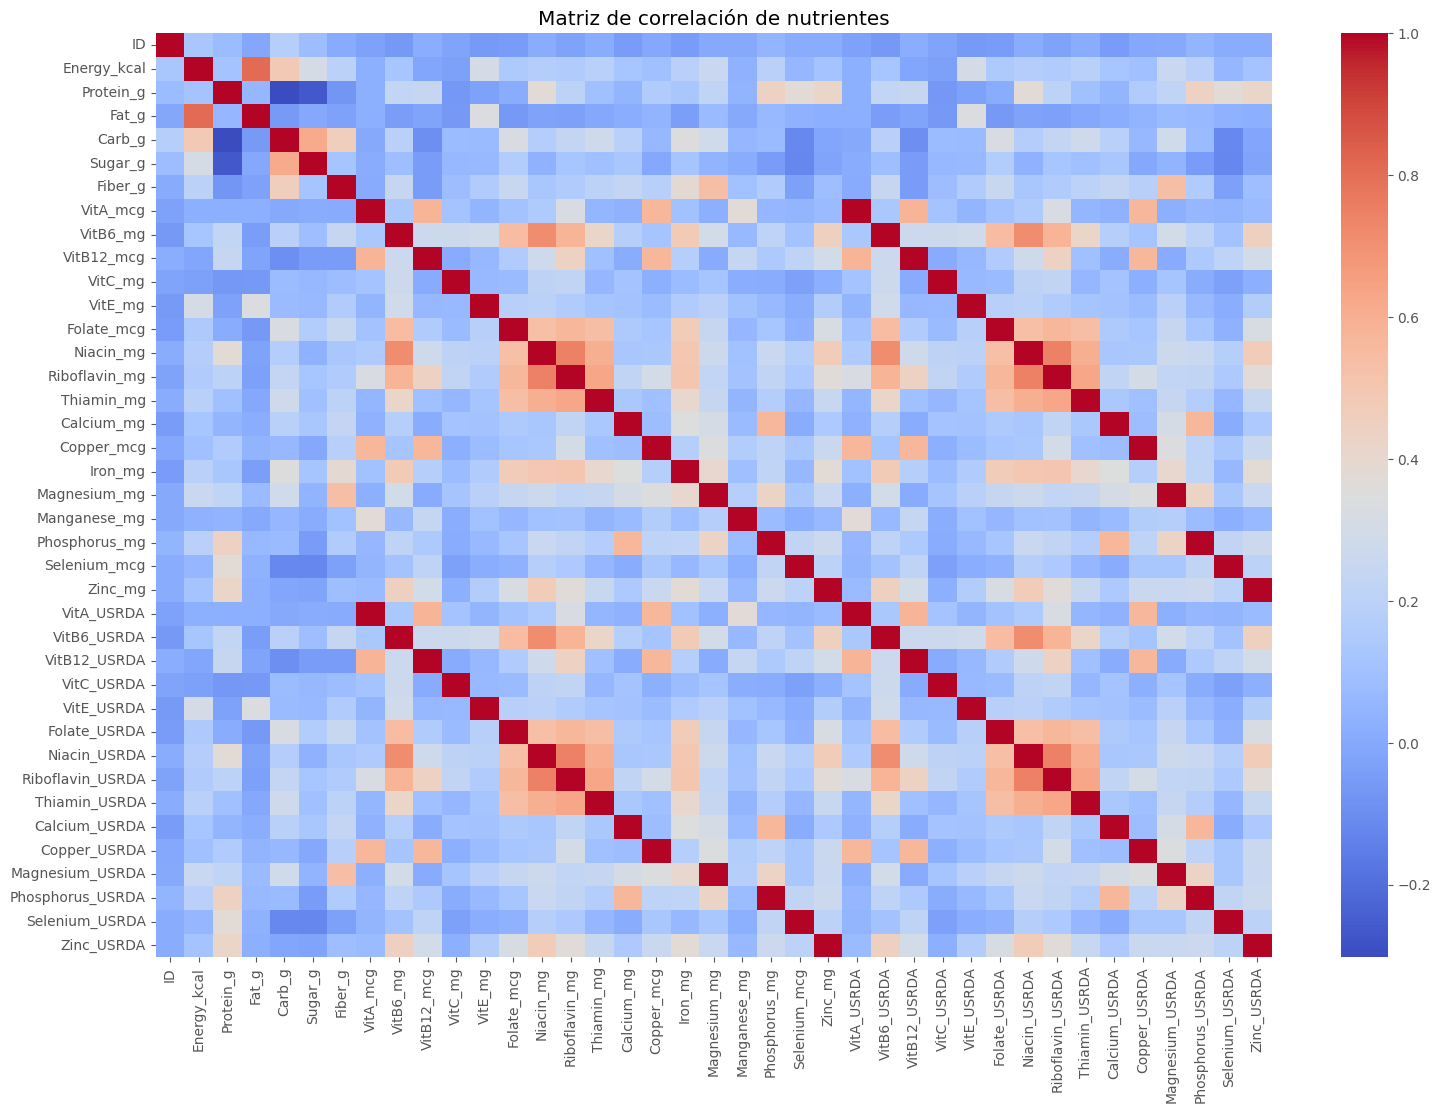


Correlaciones fuertes:
VitC_USRDA        VitC_mg             1.000000
VitC_mg           VitC_USRDA          1.000000
Folate_USRDA      Folate_mcg          1.000000
Folate_mcg        Folate_USRDA        1.000000
Thiamin_USRDA     Thiamin_mg          1.000000
Thiamin_mg        Thiamin_USRDA       1.000000
Magnesium_mg      Magnesium_USRDA     1.000000
Magnesium_USRDA   Magnesium_mg        1.000000
VitE_USRDA        VitE_mg             1.000000
VitE_mg           VitE_USRDA          1.000000
Selenium_USRDA    Selenium_mcg        1.000000
Selenium_mcg      Selenium_USRDA      1.000000
VitA_mcg          VitA_USRDA          1.000000
Copper_mcg        Copper_USRDA        1.000000
Copper_USRDA      Copper_mcg          1.000000
VitA_USRDA        VitA_mcg            1.000000
Riboflavin_mg     Riboflavin_USRDA    1.000000
Riboflavin_USRDA  Riboflavin_mg       1.000000
Phosphorus_mg     Phosphorus_USRDA    1.000000
Phosphorus_USRDA  Phosphorus_mg       1.000000
VitB6_USRDA       VitB6_mg          

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Suponiendo que tu DataFrame se llama df

# 1. Seleccionar solo columnas numéricas
df_num = df.select_dtypes(include=['float64', 'int64'])

print("Columnas numéricas:", df_num.columns.tolist())

# 2. Matriz de correlación (Pearson)
corr = df_num.corr(method='pearson')

# 3. Visualización del heatmap
plt.figure(figsize=(18, 12))
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title("Matriz de correlación de nutrientes")
plt.show()

# 4. Mostrar correlaciones fuertes (> 0.7 o < -0.7)
corr_pairs = corr.unstack().sort_values(ascending=False)

# Filtrar duplicados y correlación perfecta (1.0)
corr_pairs = corr_pairs[(corr_pairs != 1.0)]

# Filtrar correlaciones fuertes
strong_corr = corr_pairs[abs(corr_pairs) > 0.7]

print("\nCorrelaciones fuertes:")
print(strong_corr)

### Ejercicio 3

¿Qué pasa con las columnas USRDA? ¿Hay que tomar alguna decisión?

In [10]:
df_clean = df.drop(columns=[col for col in df.columns if col.endswith("_USRDA")])

### Ejercicio 4: Variables Categóricas

Podríamos analizar las variables no numéricas del dataset e intentar obtener más información, pero por simplicidad en este caso procedemos a eliminarlas. Elimina las variables de texto del dataset.

In [12]:
df_numeric = df.select_dtypes(exclude=['object'])
df_numeric

,ID,Energy_kcal,Protein_g,Fat_g,Carb_g,Sugar_g,Fiber_g,VitA_mcg,VitB6_mg,VitB12_mcg,...,Folate_USRDA,Niacin_USRDA,Riboflavin_USRDA,Thiamin_USRDA,Calcium_USRDA,Copper_USRDA,Magnesium_USRDA,Phosphorus_USRDA,Selenium_USRDA,Zinc_USRDA
0,1001,717.0,0.85,81.11,0.06,0.06,0.0,684.0,0.003,0.17,...,0.0075,0.002625,0.026154,0.004167,0.020000,0.000000,0.004762,0.034286,0.018182,0.008182
1,1002,717.0,0.85,81.11,0.06,0.06,0.0,684.0,0.003,0.13,...,0.0075,0.002625,0.026154,0.004167,0.020000,0.000018,0.004762,0.032857,0.018182,0.004545
2,1003,876.0,0.28,99.48,0.00,0.00,0.0,840.0,0.001,0.01,...,0.0000,0.000188,0.003846,0.000833,0.003333,0.000001,0.000000,0.004286,0.000000,0.000909
3,1004,353.0,21.40,28.74,2.34,0.50,0.0,198.0,0.166,1.22,...,0.0900,0.063500,0.293846,0.024167,0.440000,0.000044,0.054762,0.552857,0.263636,0.241818
4,1005,371.0,23.24,29.68,2.79,0.51,0.0,292.0,0.065,1.26,...,0.0500,0.007375,0.270000,0.011667,0.561667,0.000027,0.057143,0.644286,0.263636,0.236364
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8613,83110,305.0,18.50,25.10,0.00,0.00,0.0,47.0,0.410,12.00,...,0.0375,0.206250,0.146154,0.016667,0.055000,0.000111,0.142857,0.362857,1.334545,0.100000
8614,90240,111.0,20.54,0.84,5.41,0.00,0.0,2.0,0.112,2.15,...,0.0500,0.067250,0.018462,0.010000,0.008333,0.000037,0.088095,0.608571,0.394545,0.140909
8615,90480,269.0,0.00,0.00,73.14,73.20,0.0,0.0,0.000,0.00,...,0.0000,0.006250,0.046154,0.108333,0.010833,0.000022,0.023810,0.011429,0.012727,0.017273
8616,90560,90.0,16.10,1.40,2.00,0.00,0.0,30.0,0.130,0.50,...,0.0150,0.087500,0.092308,0.008333,0.008333,0.000444,0.595238,0.388571,0.498182,0.090909


### Ejercicio 5: Distribuciones

Analiza la distribución de las variables/columnas/features restantes. Recuerda que PCA es altamente sensible a las escala, así que transforma aquellas variables que creas necesario antes de proceder a escalarlas.


                   count          mean          std     min          25%  \
ID                8618.0  15467.757368  9221.428766  1001.0  8695.250000   
Energy_kcal       8618.0    226.438617   169.388910     0.0    93.000000   
Protein_g         8618.0     11.523910    10.550590     0.0     2.470000   
Fat_g             8618.0     10.647024    15.866353     0.0     0.992500   
Carb_g            8618.0     21.819062    27.239000     0.0     0.040000   
Sugar_g           8618.0      6.560253    13.602098     0.0     0.000000   
Fiber_g           8618.0      2.023242     4.313670     0.0     0.000000   
VitA_mcg          8618.0     93.968786   779.362205     0.0     0.000000   
VitB6_mg          8618.0      0.264369     0.478614     0.0     0.034250   
VitB12_mcg        8618.0      1.225260     4.319183     0.0     0.000000   
VitC_mg           8618.0      7.925377    57.582758     0.0     0.000000   
VitE_mg           8618.0      0.872329     3.849028     0.0     0.000000   
Folate_mcg  

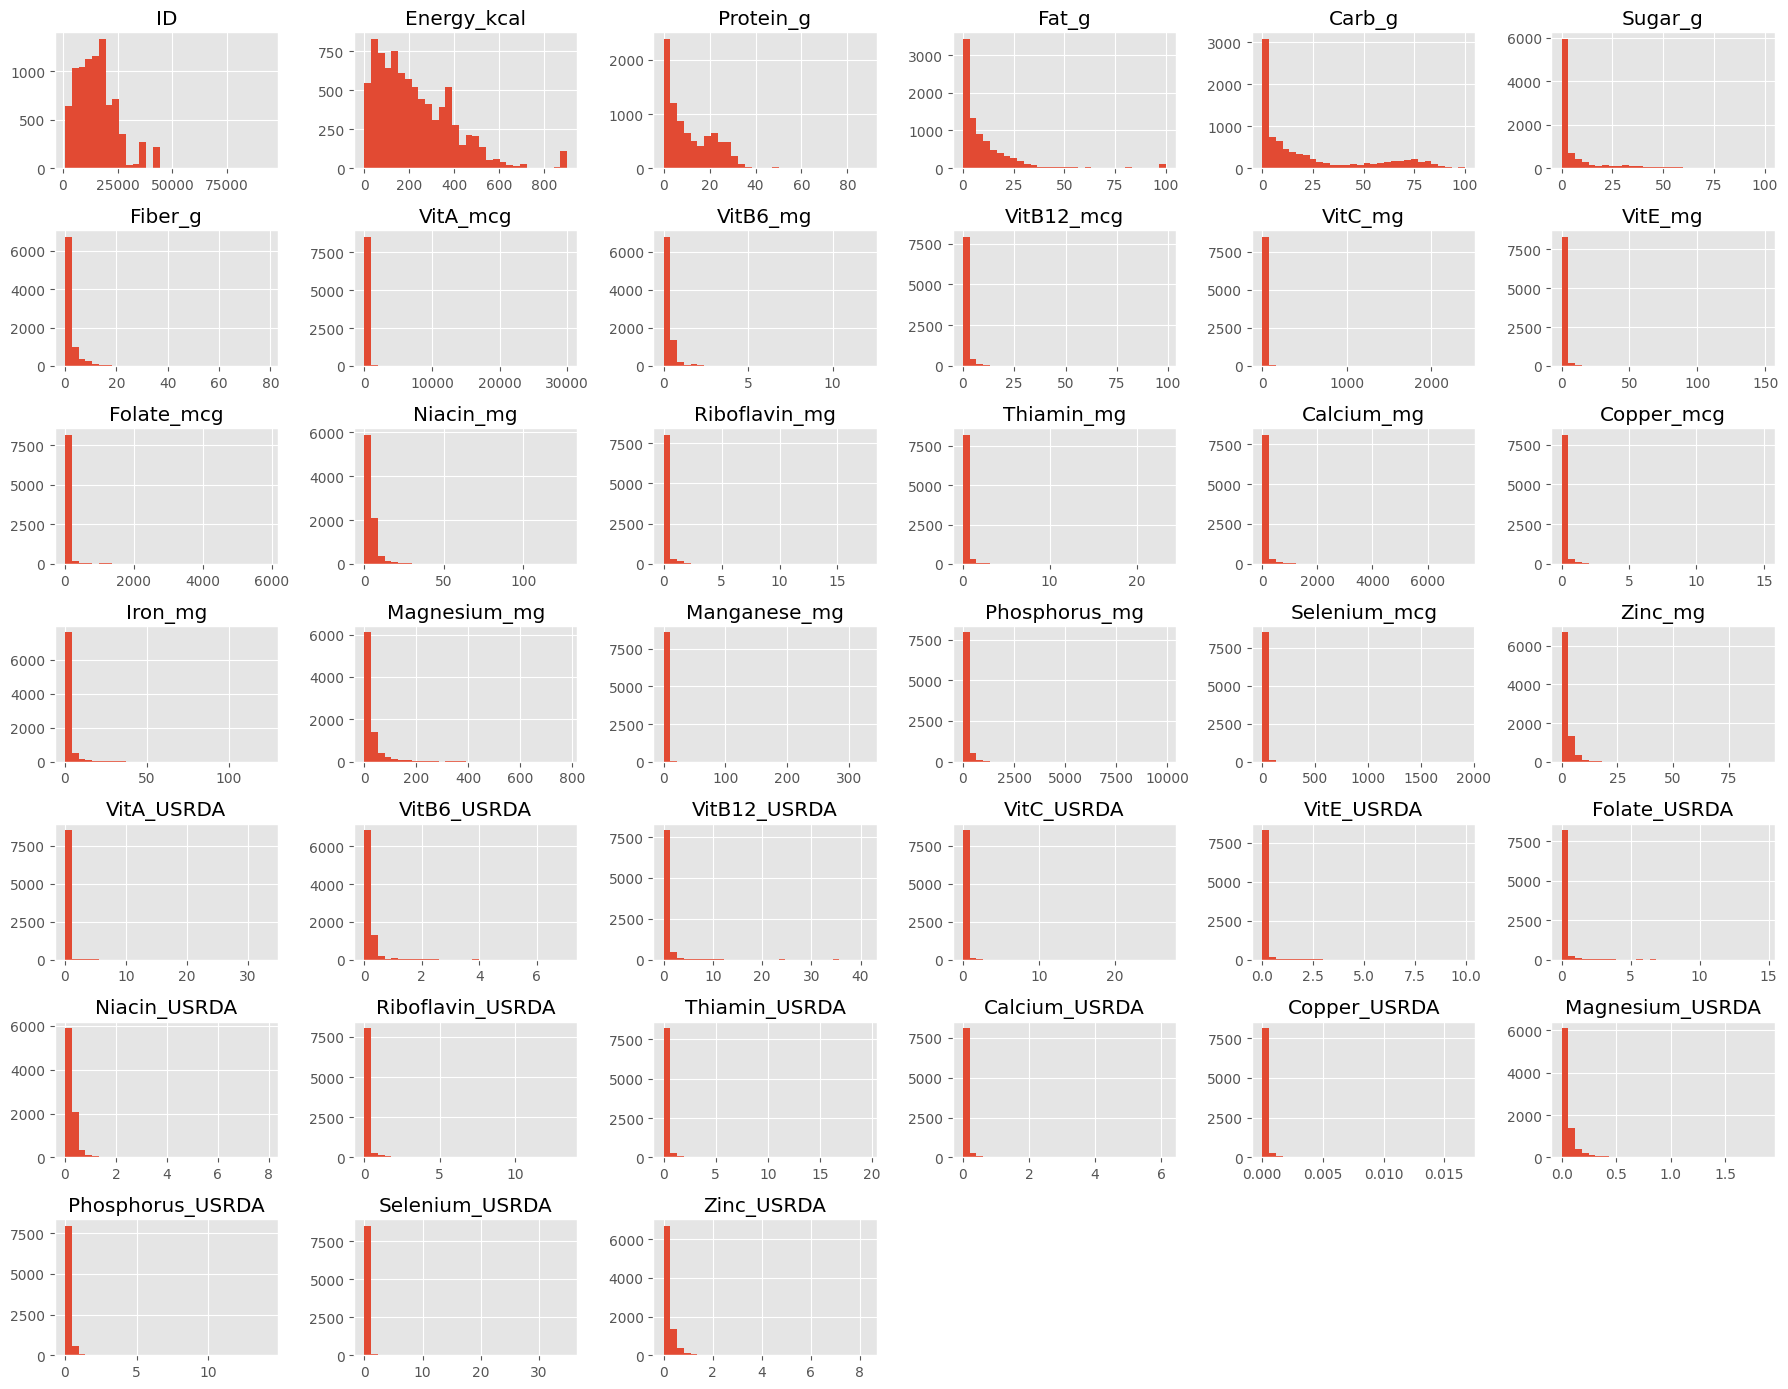

In [13]:
# Estadísticos básicos
print(df_numeric.describe().T)

# Histograma de todas las variables
df_numeric.hist(figsize=(18, 14), bins=30)
plt.tight_layout()
plt.show()


In [14]:
cols_log = [col for col in df_numeric.columns if df_numeric[col].skew() > 1]

df_transformed = df_numeric.copy()

for col in cols_log:
    df_transformed[col] = np.log1p(df_transformed[col])  # log(1+x)

In [15]:
cols_sqrt = [col for col in df_numeric.columns 
             if 0.5 < df_numeric[col].skew() <= 1]

for col in cols_sqrt:
    df_transformed[col] = np.sqrt(df_transformed[col])

### Ejercicio 6: Estandarizado
Estandariza cada variable. (No es necesario que dividas en train y test por simplificar).

In [19]:
from sklearn.preprocessing import StandardScaler

# Suponiendo que df_transformed contiene las variables ya transformadas (log, sqrt, etc.)
scaler = StandardScaler()

df_scaled = scaler.fit_transform(df_transformed)

# Si quieres mantenerlo como DataFrame:
df_scaled = pd.DataFrame(df_scaled, columns=df_transformed.columns)

df_scaled.head()

,ID,Energy_kcal,Protein_g,Fat_g,Carb_g,Sugar_g,Fiber_g,VitA_mcg,VitB6_mg,VitB12_mcg,...,Folate_USRDA,Niacin_USRDA,Riboflavin_USRDA,Thiamin_USRDA,Calcium_USRDA,Copper_USRDA,Magnesium_USRDA,Phosphorus_USRDA,Selenium_USRDA,Zinc_USRDA
0,-3.480717,1.540414,-1.379699,2.222526,-1.279339,-0.751381,-0.817818,2.363105,-0.811366,-0.453749,...,-0.370982,-0.908747,-0.657634,-0.662004,-0.308239,-0.312588,-0.657347,-0.935289,-0.728859,-0.767043
1,-3.479343,1.540414,-1.379699,2.222526,-1.279339,-0.751381,-0.817818,2.363105,-0.811366,-0.506894,...,-0.370982,-0.908747,-0.657634,-0.662004,-0.308239,-0.283509,-0.657347,-0.943791,-0.728859,-0.787228
2,-3.477969,1.745661,-1.728220,2.393490,-1.315522,-0.796963,-0.817818,2.463472,-0.819681,-0.678411,...,-0.406514,-0.921739,-0.777857,-0.678859,-0.464122,-0.310770,-0.705592,-1.116339,-0.811468,-0.807485
3,-3.476598,0.814824,0.980084,1.362565,-0.566664,-0.479778,-0.817818,1.758419,-0.184016,0.524785,...,0.003292,-0.594143,0.610310,-0.562034,2.954611,-0.239893,-0.164140,1.564362,0.261316,0.397249
4,-3.475227,0.865713,1.054782,1.388915,-0.488178,-0.474580,-0.817818,1.947668,-0.561485,0.552068,...,-0.174499,-0.883521,0.508555,-0.624284,3.722071,-0.268970,-0.141241,1.916255,0.261316,0.372659


### Ejercicio 7: Implementación del PCA
Prueba a montar un PCA con todos los componentes. Para ello utiliza los datos previamente transformados y escalados.

In [20]:

# Suponiendo que df_scaled es tu DataFrame ya transformado y estandarizado
# (y que df_scaled es un DataFrame, no un array)

# 1. Crear el modelo PCA con todos los componentes
pca = PCA(n_components=df_scaled.shape[1])

# 2. Ajustar el PCA
pca.fit(df_scaled)

# 3. Transformar los datos
df_pca = pca.transform(df_scaled)

# Convertir a DataFrame para comodidad
df_pca = pd.DataFrame(df_pca, 
                      columns=[f"PC{i+1}" for i in range(df_scaled.shape[1])])

df_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC30,PC31,PC32,PC33,PC34,PC35,PC36,PC37,PC38,PC39
0,-2.872949,-0.041708,-1.059564,2.071717,4.316022,-1.091657,1.947041,1.691916,-1.727677,0.739112,...,0.056493,0.129156,0.149302,-0.417508,-0.133305,-0.148582,0.017059,-0.018630,-0.004014,0.002193
1,-2.856397,0.017080,-1.025593,2.067338,4.304479,-1.034733,1.962871,1.692802,-1.746321,0.758139,...,0.044740,0.137827,0.133385,-0.395008,-0.154722,-0.175715,0.011337,-0.016467,-0.003554,0.001826
2,-3.783940,0.019644,-1.713222,1.630430,5.214884,-0.210496,1.937739,1.490594,-2.082953,0.981606,...,0.092190,0.119968,-0.065519,-0.435743,-0.003841,-0.107951,-0.006050,-0.014534,-0.001705,0.001497
3,1.661086,-0.848726,0.582730,2.815806,1.032576,-3.945505,2.637959,-0.053281,-1.992908,-0.617967,...,-0.033996,-0.095094,-0.070448,0.034358,0.124684,0.003629,-0.000824,-0.003682,0.002364,-0.017286
4,1.414139,-0.688807,0.940228,3.345741,1.222156,-4.348554,3.254416,-0.483591,-2.027583,-0.633037,...,0.010452,-0.116656,-0.080985,0.094218,-0.169685,0.106469,0.024970,-0.007892,-0.017519,-0.018223


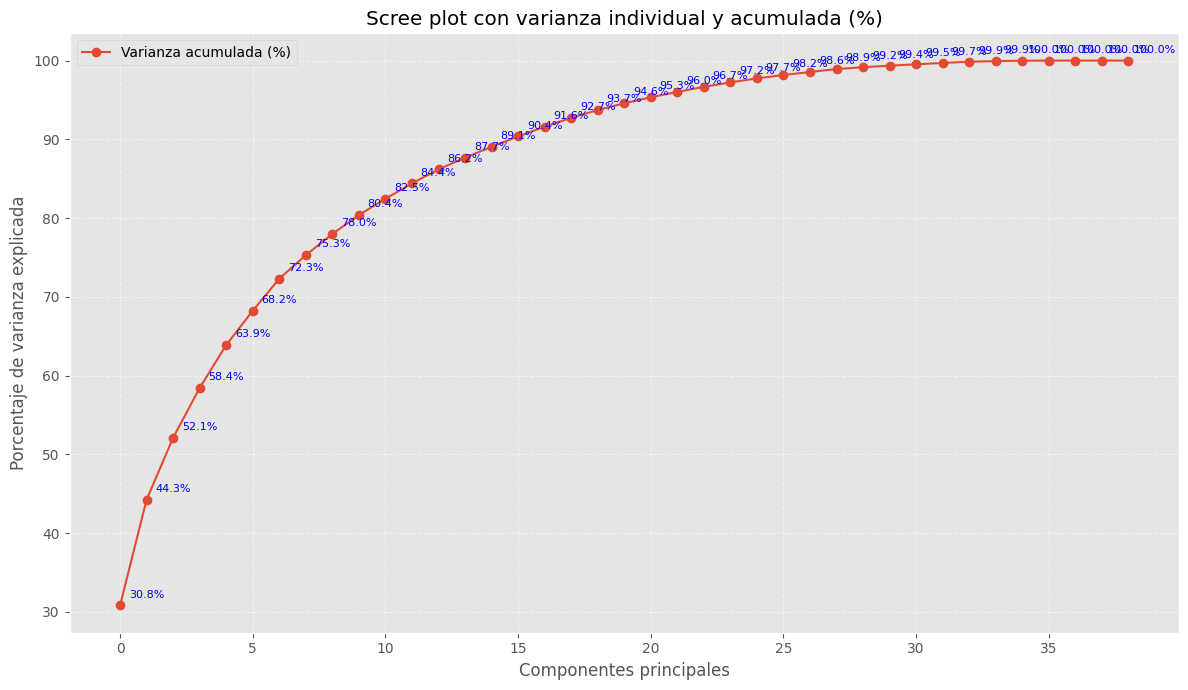

In [26]:
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# df_scaled es tu DataFrame ya transformado y estandarizado

# 1. Crear el PCA con todos los componentes
pca = PCA(n_components=df_scaled.shape[1])
pca.fit(df_scaled)

# 2. Varianza explicada
explained = pca.explained_variance_ratio_ * 100
explained_cum = np.cumsum(explained)

# 3. Gráfico con porcentajes individuales y acumulados
plt.figure(figsize=(12, 7))

# Línea de varianza acumulada
plt.plot(explained_cum, marker='o', label='Varianza acumulada (%)')

# Etiquetas de porcentaje acumulado
for i, v in enumerate(explained_cum):
    plt.text(i + 1, v + 1, f"{v:.1f}%", ha='center', fontsize=8, color='blue')

plt.xlabel("Componentes principales")
plt.ylabel("Porcentaje de varianza explicada")
plt.title("Scree plot con varianza individual y acumulada (%)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

### Ejercicio 8

Muestra en un dataframe la relación de cada componente con cada feature. En general, este paso no lo haremos salvo que sea necesario a posteriori explicar la influencia de alguna componente en función de las features originales, pero ahora, muéstralas.

In [27]:
import pandas as pd
import numpy as np

# Suponiendo que df_scaled es tu DataFrame estandarizado
# y que pca es el modelo PCA ya ajustado

# Matriz de componentes (loadings)
loadings = pca.components_

# Convertir a DataFrame
loadings_df = pd.DataFrame(
    loadings,
    columns=df_scaled.columns,
    index=[f"PC{i+1}" for i in range(loadings.shape[0])]
)

loadings_df


,ID,Energy_kcal,Protein_g,Fat_g,Carb_g,Sugar_g,Fiber_g,VitA_mcg,VitB6_mg,VitB12_mcg,...,Folate_USRDA,Niacin_USRDA,Riboflavin_USRDA,Thiamin_USRDA,Calcium_USRDA,Copper_USRDA,Magnesium_USRDA,Phosphorus_USRDA,Selenium_USRDA,Zinc_USRDA
PC1,0.013806,0.136587,0.194512,0.094794,0.005825,-0.009648,0.057927,0.069048,0.222280,0.175476,...,0.165456,0.232327,0.224072,0.190692,0.101612,0.109633,0.161987,0.204592,0.159721,0.209638
PC2,-0.045818,-0.013454,-0.228888,-0.126858,0.350215,0.256013,0.303207,0.105518,0.008606,-0.215081,...,0.194612,-0.052766,0.066562,0.136018,0.161934,0.062289,0.164659,-0.059494,-0.223630,-0.126038
PC3,0.110031,0.219547,0.153860,0.180605,0.127730,-0.027360,0.168401,-0.186482,-0.197565,-0.214108,...,-0.114549,-0.137048,-0.195927,-0.065014,0.085732,0.060180,0.261213,0.214885,0.052794,-0.013747
PC4,-0.197891,-0.221162,-0.011192,-0.116469,-0.173885,-0.169695,-0.117584,0.299728,-0.086029,0.093632,...,-0.064445,-0.187736,-0.083764,-0.293235,0.134804,0.277338,0.093915,0.088147,0.110348,0.035768
PC5,-0.071708,0.310501,-0.044033,0.412551,-0.030170,0.111037,-0.068361,0.100814,-0.007032,0.034906,...,-0.043675,-0.018031,-0.008682,-0.048698,0.035839,0.013281,-0.046586,-0.018144,-0.020698,-0.002250
PC6,0.244038,-0.013904,-0.075810,-0.047846,0.022899,-0.048190,0.085196,-0.185172,-0.022808,0.051923,...,0.032808,0.012528,0.018222,0.021109,-0.370793,0.502986,0.066705,-0.133137,-0.053851,0.053833
PC7,-0.048520,0.181362,0.020557,0.157329,0.173238,0.196297,-0.070367,0.255147,-0.199674,0.081644,...,-0.042575,-0.085417,0.203028,0.052945,0.201451,0.188371,-0.188317,0.048395,-0.030402,-0.125573
PC8,-0.117940,-0.053044,-0.031192,-0.067311,0.010681,-0.125676,-0.009752,0.257191,-0.050743,-0.148451,...,0.284830,0.038642,-0.015987,0.108449,-0.324662,-0.082476,-0.109948,-0.124558,0.257972,-0.249107
PC9,0.612850,0.183918,0.039886,0.082105,0.200548,0.269072,0.086318,0.154093,-0.062794,0.143338,...,0.019169,-0.056704,-0.104660,-0.194509,-0.197745,-0.102985,-0.145675,-0.087951,0.095527,-0.020101
PC10,0.058050,0.084511,0.105998,0.149024,-0.072892,-0.200741,-0.094119,0.129255,-0.021038,-0.220416,...,-0.357919,0.155701,0.044093,0.162593,-0.100797,0.102149,0.066128,0.111786,0.061398,-0.318981


### Ejercicio 9: Aportación de cada PCA
Visualiza en un diagrama de líneas la suma acumulada de la varianza explicativa del PCA.

Si tuviéses que quedarte con 70-75 % de la varianza original, ¿con cuántos Principal Components te quedarías?

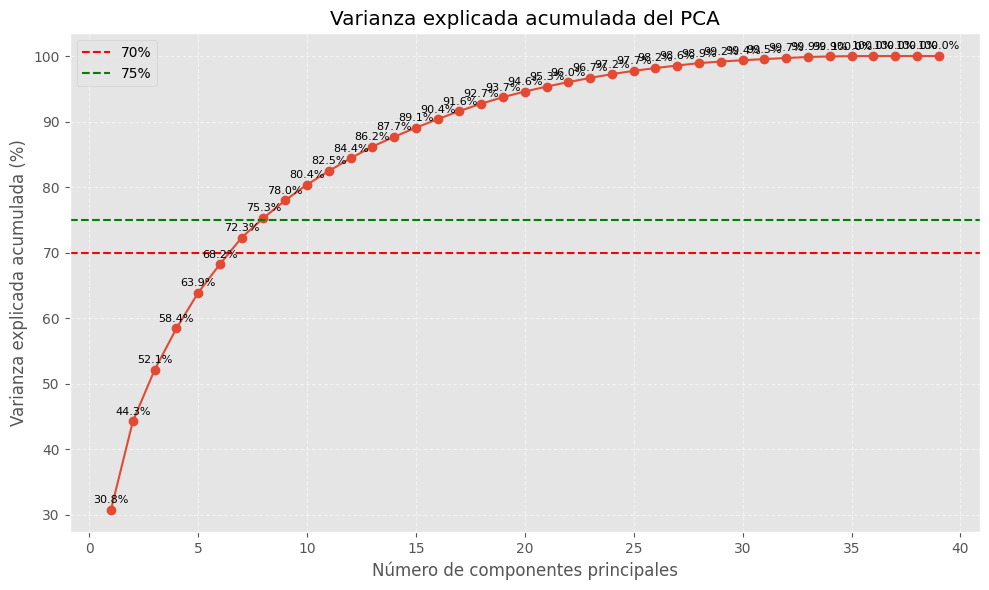

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Varianza explicada individual (%) y acumulada (%)
explained = pca.explained_variance_ratio_ * 100
explained_cum = np.cumsum(explained)

plt.figure(figsize=(10, 6))

# Línea de varianza acumulada
plt.plot(range(1, len(explained_cum) + 1), explained_cum, marker='o')

# Etiquetas de porcentaje acumulado
for i, v in enumerate(explained_cum):
    plt.text(i + 1, v + 1, f"{v:.1f}%", ha='center', fontsize=8)

plt.axhline(70, color='red', linestyle='--', label='70%')
plt.axhline(75, color='green', linestyle='--', label='75%')

plt.xlabel("Número de componentes principales")
plt.ylabel("Varianza explicada acumulada (%)")
plt.title("Varianza explicada acumulada del PCA")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

### Ejercicio 10: Reducción de features

Crea un nuevo PCA con X Principal Components, siendo X la cantidad de PC escogidos en el apartado anterior.

Obtén el nuevo dataset con el mismo número de registros que el original, pero en este caso con X features, que representan los PC elegidos.

In [29]:
from sklearn.decomposition import PCA
import pandas as pd

# df_scaled es tu DataFrame ya transformado y estandarizado

# Crear PCA con 8 componentes
pca_8 = PCA(n_components=8)

# Ajustar el PCA
pca_8.fit(df_scaled)

# Transformar los datos
df_pca_8 = pca_8.transform(df_scaled)

# Convertir a DataFrame
df_pca_8 = pd.DataFrame(df_pca_8, 
                        columns=[f"PC{i+1}" for i in range(8)])

df_pca_8.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
0,-2.872949,-0.041708,-1.059564,2.071717,4.316022,-1.091657,1.947041,1.691916
1,-2.856397,0.017080,-1.025593,2.067338,4.304479,-1.034733,1.962871,1.692802
2,-3.783940,0.019644,-1.713222,1.630430,5.214884,-0.210496,1.937739,1.490594
3,1.661086,-0.848726,0.582730,2.815806,1.032576,-3.945505,2.637959,-0.053281
4,1.414139,-0.688807,0.940228,3.345741,1.222156,-4.348554,3.254416,-0.483591


In [30]:
var_exp_8 = pca_8.explained_variance_ratio_ * 100
var_exp_8_cum = var_exp_8.cumsum()

pd.DataFrame({
    "Componente": [f"PC{i+1}" for i in range(8)],
    "Varianza (%)": var_exp_8,
    "Acumulada (%)": var_exp_8_cum
})

,Componente,Varianza (%),Acumulada (%)
0,PC1,30.810438,30.810438
1,PC2,13.440532,44.250970
2,PC3,7.857982,52.108952
3,PC4,6.325057,58.434009
4,PC5,5.449636,63.883646
5,PC6,4.359221,68.242867
6,PC7,4.062633,72.305500
7,PC8,2.987913,75.293413
